In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import os
import math
import re
import matplotlib.pyplot as plt

from tqdm import tqdm
from glob import glob
from os.path import join

from sklearn.model_selection import train_test_split
import lightgbm as lgb

from sklearn.metrics import roc_curve, auc

In [2]:
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.linear_model import SGDClassifier

In [3]:
from model_tools.gentools import gentools as glts
from model_tools.gentools import advtools as advtls
from model_tools.plot import feature_plot as fplt
from model_tools.feature_select import feature_select as fs
from model_tools.model import model as mdl
from model_tools.model.model_monitor import ModelMonitor

C:\Users\win\Anaconda3\lib\site-packages\statsmodels\tools\_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [4]:
def perf_mean(v, fea, target, type_='pred'):
    partner_list = []
    all_list = []
    notnull_list = []
    ks_list = []
    auc_list = []

    for x in v.partner_name.unique():
        mask = (v.partner_name == x)&(pd.notnull(v[fea]))
        partner_list.append(x)

        all_list.append((v.partner_name == x).sum())
        notnull_list.append(mask.sum())
        
        try:
            if type_=='pred':
                ks_, auc_ = evaluate_performance(v.loc[mask, target].values, v.loc[mask, fea].values)
            else:
                ks_, auc_ = evaluate_performance(v.loc[mask, target].values, 1-v.loc[mask, fea].values/1000)
        except:
            ks_, auc_ = np.nan,np.nan
        ks_list.append(ks_)
        auc_list.append(auc_)

    tmpp = pd.DataFrame({'partner':partner_list,'all_list':all_list,'notnull_list':notnull_list,'ks':ks_list,'auc':auc_list}).sort_values('partner')
#     display(tmpp)
    return tmpp['ks'].mean(), tmpp['auc'].mean()

In [5]:
def LogitTransformation(prob):

    if prob <= 0 or prob >= 1:
        return 0
    y = np.log(prob/(1-prob))
    return y


def get_valid_prob(x):

    if x <= 0 or x >= 1:
        y = 0
    else:
        y = 1
    return y

In [6]:
def perf_mean(v, fea, target, func=np.nan):
    partner_list = []
    all_list = []
    notnull_list = []
    perf_list = []

    for x in v.partner_name.unique():
        all_list.append((v.partner_name == x).sum())
        mask = (v.partner_name == x)&(pd.notnull(v[fea]))
        notnull_list.append(mask.sum())
        
        if pd.isnull(func):
            func = lambda x: x

        ks_, auc_, show_list = ModelMonitor().evaluate_performance(v[mask][target], v[mask][fea].apply(func), 
                           to_plot=False, suptitle=None, bins=20, save_path=None)
        bins = show_list[3]
        bins = bins.replace('nan','np.nan')
        bins = eval(bins[bins.find('['):bins.find(']')+1])
        perf_list.extend([ks_, auc_, round(np.mean(bins[-2:])/v[mask][target].mean(),4), round(bins[-1]/v[mask][target].mean(),4)])
        
    return [round(np.mean([perf_list[i] for i in range(len(perf_list)) if i%4==c]), 5) for c in range(4)]

## cfg

In [7]:
type_ = 'C'

In [8]:
apply_date = 'into_time'
mobile = 'mobile_md5'
id_number = 'cert_no_md5'
target = flag = 'fpd30'
name = 'fpd'

## data

In [9]:
ym = pd.read_csv('E:/xyd_work/联合建模/hengchang20250310/model/al_ym_modelC/ym_prob.csv')
ym = ym[[apply_date,mobile,id_number,target,f'type{type_}_{name}model_pred','partner_name']]
ym.rename(columns={f'type{type_}_{name}model_pred':f'type{type_}_{name}model_pred_ym'}, inplace=True)
print(ym.shape)
ym.head(2)

(425555, 6)


,into_time,mobile_md5,cert_no_md5,fpd30,typeC_fpdmodel_pred_ym,partner_name
0,20241010,3cf2ed6a4ca2992d56c6c151c355016d,cf87c7b911d38dfccd8389df543cb677,0.0,0.014004,A
1,20241010,3cf2ed6a4ca2992d56c6c151c355016d,cf87c7b911d38dfccd8389df543cb677,0.0,0.014004,B


In [10]:
al = pd.read_csv('E:/xyd_work/联合建模/hengchang20250310/model/al_ym_modelC/al_prob.csv')
al = al[[apply_date,mobile,id_number,target,f'type{type_}_{name}model_pred','partner_name']]
al.rename(columns={f'type{type_}_{name}model_pred':f'type{type_}_{name}model_pred_al'}, inplace=True)
print(al.shape)
al.head(2)

(425555, 6)


,into_time,mobile_md5,cert_no_md5,fpd30,typeC_fpdmodel_pred_al,partner_name
0,20241010,3cf2ed6a4ca2992d56c6c151c355016d,cf87c7b911d38dfccd8389df543cb677,0.0,0.013665,A
1,20241010,49d0a7a1db49e066e5e463baa1e04e87,4febaf9e6ff6106af7111cdd1bee9bc8,0.0,0.009050,A


In [11]:
print(ym.shape[0])
df = ym.merge(al.drop_duplicates()).reset_index(drop=True)
print(df.shape[0])
print('')

df = df[df['partner_name']==type_]
df['month'] = df['into_time'].apply(lambda x: str(x)[:6])
df['year'] = df['into_time'].apply(lambda x: str(x)[:4])
print(f'type {type_} shape is:', df.shape)
df.head(1)

425555
425555

type C shape is: (120187, 9)


,into_time,mobile_md5,cert_no_md5,fpd30,typeC_fpdmodel_pred_ym,partner_name,typeC_fpdmodel_pred_al,month,year
4,20241010,e58f9a33f0c939e61b42a4d408694c3b,0ca0071b1f09a4cf43897594c7bb45aa,0.0,0.014951,C,0.014984,202410,2024


In [12]:
print(df.isnull().sum())
print('')

idx = df[flag]>=0
df = df[idx].reset_index(drop=True)
print(df.shape)

into_time                     0
mobile_md5                    0
cert_no_md5                   0
fpd30                     10000
typeC_fpdmodel_pred_ym     3339
partner_name                  0
typeC_fpdmodel_pred_al       13
month                         0
year                          0
dtype: int64

(110187, 9)


In [13]:
df.groupby(['month']).agg({flag:[len,sum,'mean']})

fpd30                 
          len    sum      mean
month                         
202406  16845  170.0  0.010092
202407  12216  154.0  0.012606
202408  20738  268.0  0.012923
202409  32631  452.0  0.013852
202410  27757  436.0  0.015708

In [14]:
for fea in [f'type{type_}_{name}model_pred_ym',f'type{type_}_{name}model_pred_al']:
    print(fea)
    print(df[fea].min(),df[fea].max(),df[fea].isnull().sum())
    print('='*10)

typeC_fpdmodel_pred_ym
0.0073917933421371 0.0255985383183714 3039
typeC_fpdmodel_pred_al
0.0076628197204976 0.0235510878558966 10


In [15]:
for v in [df]:
    for fea in [f'type{type_}_{name}model_pred_ym',f'type{type_}_{name}model_pred_al']:
        
        v[fea] = v[fea].fillna(0)
        v[f'{fea}_ori'] = v[fea]
        v[f'{fea}_valid'] = v[fea].apply(lambda x: get_valid_prob(x))
        v[fea] = v[fea].apply(lambda x: LogitTransformation(x))

## sample

In [16]:
x_train = df
print(x_train.shape)
x_train.head(2)

(110187, 13)


,into_time,mobile_md5,cert_no_md5,fpd30,typeC_fpdmodel_pred_ym,partner_name,typeC_fpdmodel_pred_al,month,year,typeC_fpdmodel_pred_ym_ori,typeC_fpdmodel_pred_ym_valid,typeC_fpdmodel_pred_al_ori,typeC_fpdmodel_pred_al_valid
0,20241010,e58f9a33f0c939e61b42a4d408694c3b,0ca0071b1f09a4cf43897594c7bb45aa,0.0,-4.187885,C,-4.185678,202410,2024,0.014951,1,0.014984,1
1,20241010,98421b12e6c43e7e2cce70e769b3d9ad,e17fcc114032c3eb66edfe36a4a9a73e,0.0,0.000000,C,-4.000420,202410,2024,0.000000,0,0.017979,1


## model

In [17]:
feas = [
f'type{type_}_{name}model_pred_ym',
f'type{type_}_{name}model_pred_ym_valid',    
    
f'type{type_}_{name}model_pred_al',
f'type{type_}_{name}model_pred_al_valid',

]

len(feas)

4

In [18]:
from sklearn.linear_model import LogisticRegression
params = {'penalty': 'l1',
 'tol': 0.0025,
 'C': 6.0,
 'solver': 'saga',
 'max_iter': 200,
 'warm_start': True,
 'random_state': 2020}

In [19]:
model = LogisticRegression(**params)
model.fit(x_train[feas], x_train[target])  

LogisticRegression(C=6.0, max_iter=200, penalty='l1', random_state=2020,
                   solver='saga', tol=0.0025, warm_start=True)

In [20]:
print(feas)
print(model.coef_, model.intercept_)

['typeC_fpdmodel_pred_ym', 'typeC_fpdmodel_pred_ym_valid', 'typeC_fpdmodel_pred_al', 'typeC_fpdmodel_pred_al_valid']
[[2.00025796 8.56188887 1.62229613 4.17048149]] [-1.54055334]


In [21]:
for dd in [x_train, df]:
    fea = 'pred_prob'
    dd['pred_prob'] = model.predict_proba(dd[feas])[:,1:]

    idx = dd[[c for c in df if re.search('valid',c)]].sum(axis=1)==0
    dd.loc[idx,'pred_prob'] = np.nan  

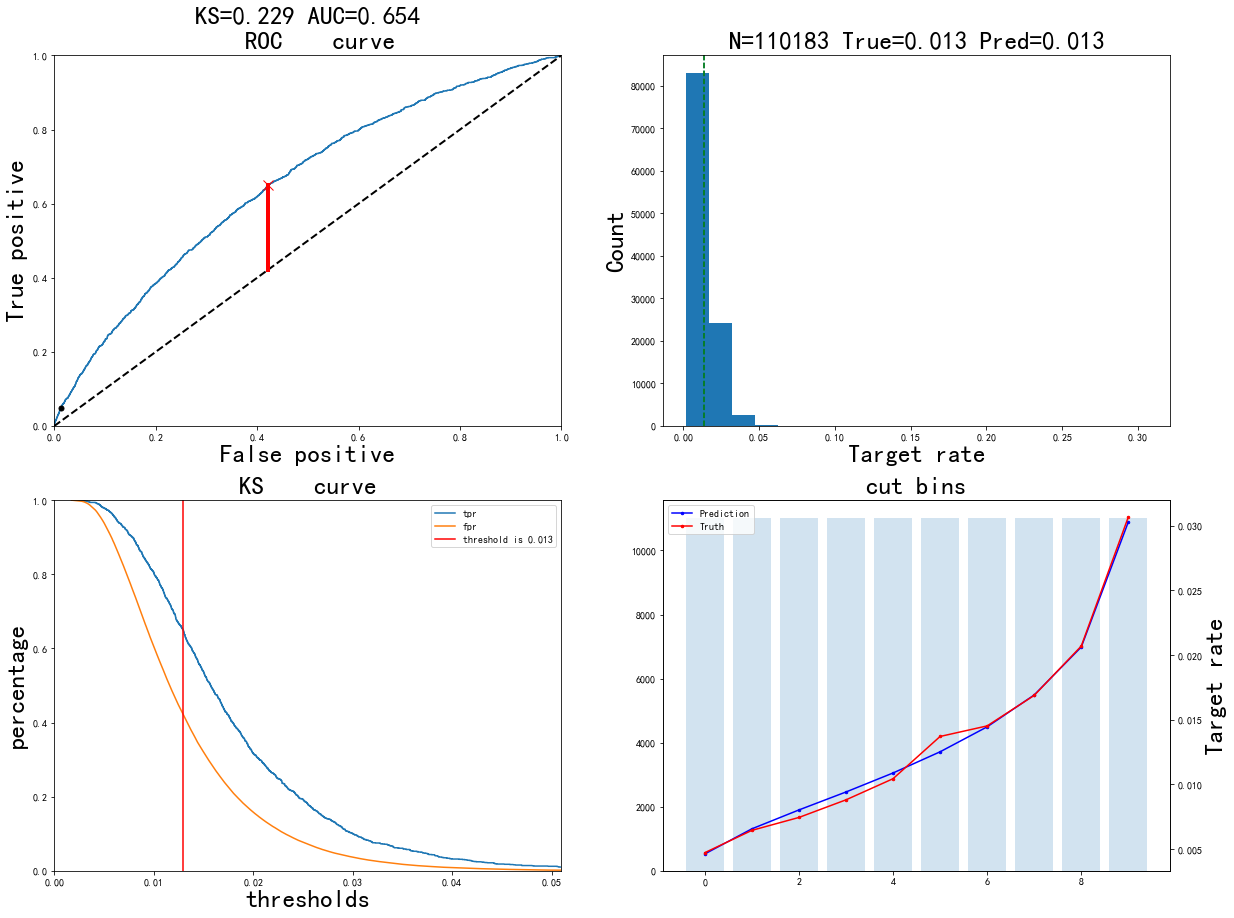

,合作方,样本量,覆盖度,坏样本数量,ks,auc,90_lift,95_lift
0,C,110187,100.0%,1480.0,0.229477,0.6536,1.9121,2.2836


mean: ks = 0.22948, auc = 0.6536, 90_lift = 1.9121, 95_list = 2.2836


In [22]:
v = x_train
partner_list = []
all_list = []
notnull_list = []
perf_list = []

for x in v.partner_name.unique():
    all_list.append((v.partner_name == x).sum())
    mask = (v.partner_name == x)&(pd.notnull(v[fea]))
    notnull_list.append(mask.sum())


    ks_, auc_, _, show_list= ModelMonitor().evaluate_performance(v[mask][target], v[mask][fea], 
                           to_plot=True, suptitle=None, bins=10, save_path=None)
    
    
    display(_)
    bins = show_list[3]
    bins = eval(bins[bins.find('['):bins.find(']')+1])
    perf_list.extend([ks_, auc_, round(np.mean(bins[-2:])/v[mask][target].mean(),4), round(bins[-1]/v[mask][target].mean(),4)])
    partner_list.append(x)

tmpp = pd.DataFrame({'合作方':partner_list,'样本量':all_list,'覆盖度':notnull_list,
                     'ks':[perf_list[i] for i in range(len(perf_list)) if i%4==0],
                     'auc':[perf_list[i] for i in range(len(perf_list)) if i%4==1],
                     '90_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==2],
                     '95_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==3]}).sort_values('合作方')
tmpp['覆盖度'] = tmpp['覆盖度']/tmpp['样本量']
tmpp['覆盖度'] = tmpp['覆盖度'].apply(lambda x: str(round(x*100, 2))+'%')
tmpp = tmpp.merge(v.groupby(['partner_name'], as_index=False).agg({target:sum}).\
                  rename(columns={'partner_name':'合作方', target:'坏样本数量'}))
tmpp = tmpp[['合作方', '样本量', '覆盖度', '坏样本数量', 'ks', 'auc', '90_lift', '95_lift']]

display(tmpp)
print('mean: ks = {}, auc = {}, 90_lift = {}, 95_list = {}'.\
      format(round(tmpp['ks'].mean(),5), round(tmpp['auc'].mean(),5), 
             round(tmpp['90_lift'].mean(),5), round(tmpp['95_lift'].mean(),5)))

In [23]:
model.feas = feas

In [24]:
import joblib

In [25]:
joblib.dump(model,'./model.pkl')

['./model.pkl']

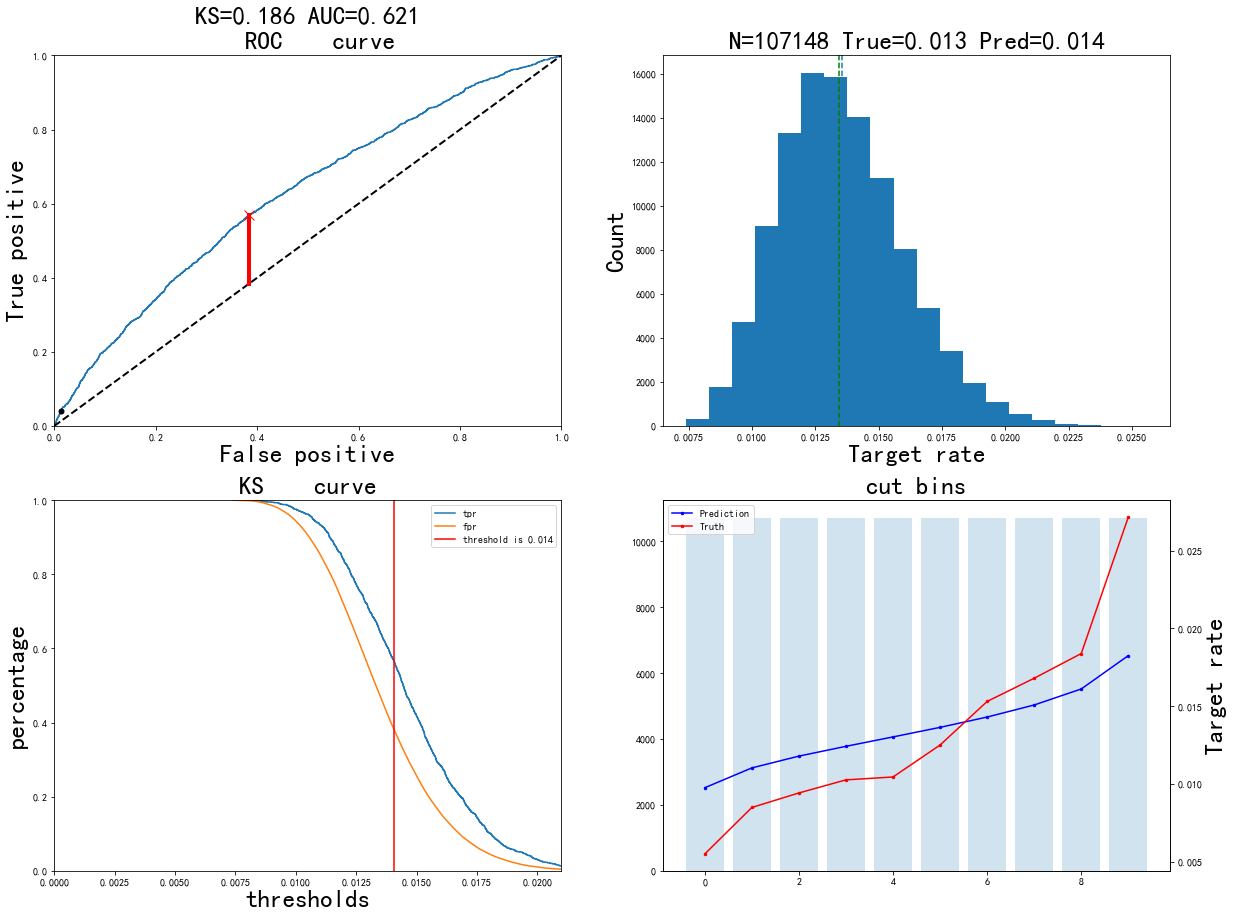

,合作方,样本量,覆盖度,坏样本数量,ks,auc,90_lift,95_lift
0,C,110187,97.24%,1480.0,0.185616,0.6214,1.6956,2.0222


mean: ks = 0.18562, auc = 0.6214, 90_lift = 1.6956, 95_list = 2.0222


In [26]:
fea = feas[0]+'_ori'

v = x_train
partner_list = []
all_list = []
notnull_list = []
perf_list = []

for x in v.partner_name.unique():
    all_list.append((v.partner_name == x).sum())
    mask = (v.partner_name == x)&(pd.notnull(v[fea]))&(v[fea]>0)
    notnull_list.append(mask.sum())


    ks_, auc_, _, show_list= ModelMonitor().evaluate_performance(v[mask][target], v[mask][fea], 
                           to_plot=True, suptitle=None, bins=10, save_path=None)
    
    
    display(_)
    bins = show_list[3]
    bins = eval(bins[bins.find('['):bins.find(']')+1])
    perf_list.extend([ks_, auc_, round(np.mean(bins[-2:])/v[mask][target].mean(),4), round(bins[-1]/v[mask][target].mean(),4)])
    partner_list.append(x)

tmpp = pd.DataFrame({'合作方':partner_list,'样本量':all_list,'覆盖度':notnull_list,
                     'ks':[perf_list[i] for i in range(len(perf_list)) if i%4==0],
                     'auc':[perf_list[i] for i in range(len(perf_list)) if i%4==1],
                     '90_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==2],
                     '95_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==3]}).sort_values('合作方')
tmpp['覆盖度'] = tmpp['覆盖度']/tmpp['样本量']
tmpp['覆盖度'] = tmpp['覆盖度'].apply(lambda x: str(round(x*100, 2))+'%')
tmpp = tmpp.merge(v.groupby(['partner_name'], as_index=False).agg({target:sum}).\
                  rename(columns={'partner_name':'合作方', target:'坏样本数量'}))
tmpp = tmpp[['合作方', '样本量', '覆盖度', '坏样本数量', 'ks', 'auc', '90_lift', '95_lift']]

display(tmpp)
print('mean: ks = {}, auc = {}, 90_lift = {}, 95_list = {}'.\
      format(round(tmpp['ks'].mean(),5), round(tmpp['auc'].mean(),5), 
             round(tmpp['90_lift'].mean(),5), round(tmpp['95_lift'].mean(),5)))

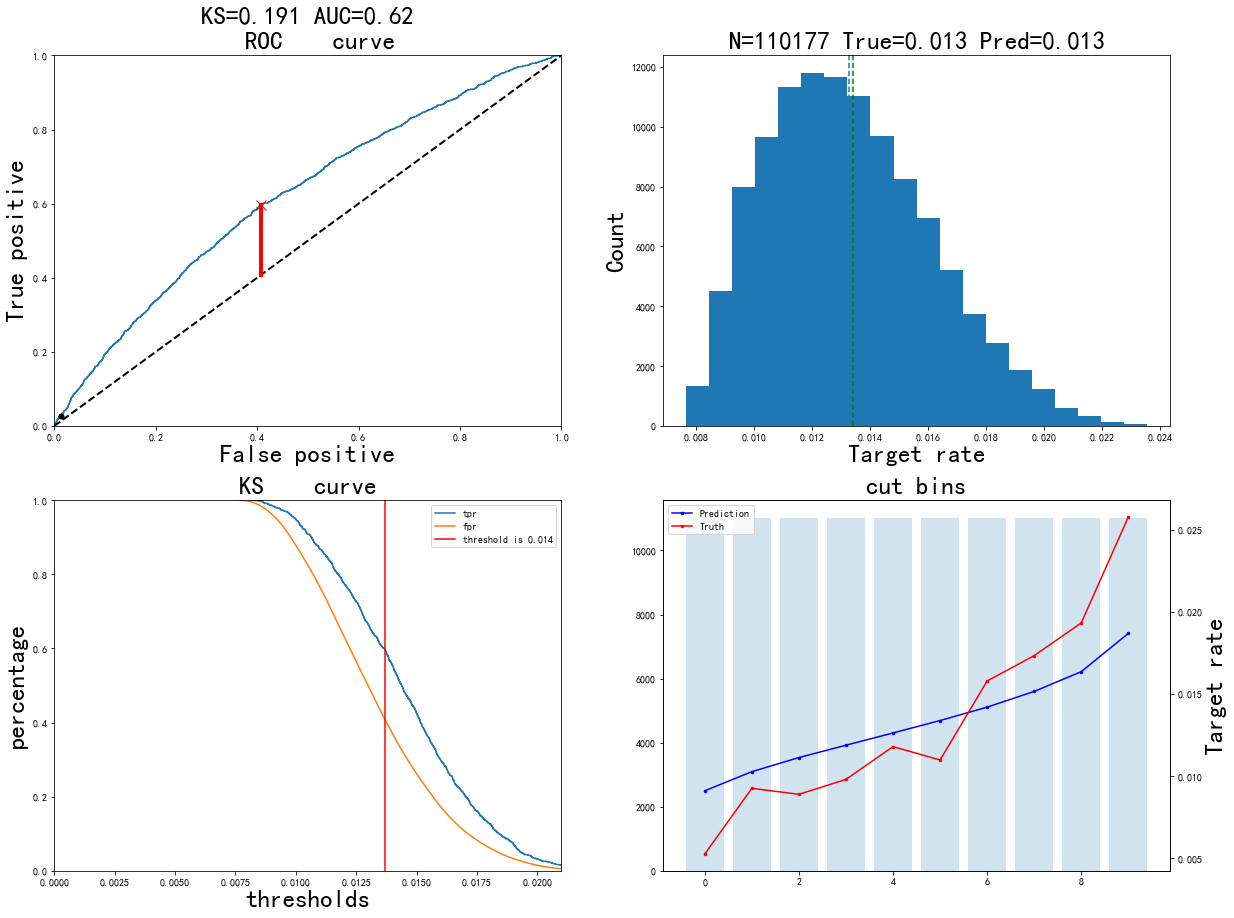

,合作方,样本量,覆盖度,坏样本数量,ks,auc,90_lift,95_lift
0,C,110187,99.99%,1480.0,0.190601,0.6197,1.6801,1.9202


mean: ks = 0.1906, auc = 0.6197, 90_lift = 1.6801, 95_list = 1.9202


In [27]:
fea = feas[2]+'_ori'

v = x_train
partner_list = []
all_list = []
notnull_list = []
perf_list = []

for x in v.partner_name.unique():
    all_list.append((v.partner_name == x).sum())
    mask = (v.partner_name == x)&(pd.notnull(v[fea]))&(v[fea]>0)
    notnull_list.append(mask.sum())


    ks_, auc_, _, show_list= ModelMonitor().evaluate_performance(v[mask][target], v[mask][fea], 
                           to_plot=True, suptitle=None, bins=10, save_path=None)
    
    
    display(_)
    bins = show_list[3]
    bins = eval(bins[bins.find('['):bins.find(']')+1])
    perf_list.extend([ks_, auc_, round(np.mean(bins[-2:])/v[mask][target].mean(),4), round(bins[-1]/v[mask][target].mean(),4)])
    partner_list.append(x)

tmpp = pd.DataFrame({'合作方':partner_list,'样本量':all_list,'覆盖度':notnull_list,
                     'ks':[perf_list[i] for i in range(len(perf_list)) if i%4==0],
                     'auc':[perf_list[i] for i in range(len(perf_list)) if i%4==1],
                     '90_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==2],
                     '95_lift': [perf_list[i] for i in range(len(perf_list)) if i%4==3]}).sort_values('合作方')
tmpp['覆盖度'] = tmpp['覆盖度']/tmpp['样本量']
tmpp['覆盖度'] = tmpp['覆盖度'].apply(lambda x: str(round(x*100, 2))+'%')
tmpp = tmpp.merge(v.groupby(['partner_name'], as_index=False).agg({target:sum}).\
                  rename(columns={'partner_name':'合作方', target:'坏样本数量'}))
tmpp = tmpp[['合作方', '样本量', '覆盖度', '坏样本数量', 'ks', 'auc', '90_lift', '95_lift']]

display(tmpp)
print('mean: ks = {}, auc = {}, 90_lift = {}, 95_list = {}'.\
      format(round(tmpp['ks'].mean(),5), round(tmpp['auc'].mean(),5), 
             round(tmpp['90_lift'].mean(),5), round(tmpp['95_lift'].mean(),5)))